Loading the given data

In [7]:

import pandas as pd

try:
    df = pd.read_csv('heartdisease.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'heartdisease.csv' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

,HeartDiseaseorAttack,HighBP,HighChol,BMI,Smoker,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,0.0,18.0,15.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,0.0,30.0,30.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,27.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,11.0,5.0,4.0


(253680, 16)


Objective 1 Probability of getting heart attack

In [9]:
#Probability of getting heart attack

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

# Assuming you have your data loaded in 'df' and preprocessed
X = df.drop(columns=['HeartDiseaseorAttack'])  # Features
y = df['HeartDiseaseorAttack']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# To get probability estimates:
probabilities = model.predict_proba(X_test)
print(f"Probability :{probabilities}")
# probabilities[:, 1] gives the probability of having a heart attack

Accuracy: 0.9062795648060549
Probability :[[0.96937883 0.03062117]
 [0.84652641 0.15347359]
 [0.99425554 0.00574446]
 ...
 [0.97189806 0.02810194]
 [0.81719577 0.18280423]
 [0.99437381 0.00562619]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Objective 2:Important drivers for heart attack-Multivariate analysis

**Data exploration**


Explores the dataset to understand its structure and identify numerical features related to heart attacks.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   BMI                   253680 non-null  float64
 4   Smoker                253680 non-null  float64
 5   Diabetes              253680 non-null  float64
 6   PhysActivity          253680 non-null  float64
 7   Fruits                253680 non-null  float64
 8   Veggies               253680 non-null  float64
 9   HvyAlcoholConsump     253680 non-null  float64
 10  MentHlth              253680 non-null  float64
 11  PhysHlth              253680 non-null  float64
 12  Sex                   253680 non-null  float64
 13  Age                   253680 non-null  float64
 14  Education             253680 non-null  float64
 15  

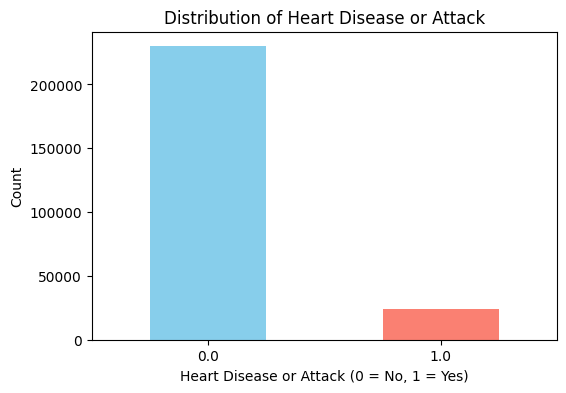

In [2]:
# Examine data types and summary statistics
print(df.info())
print(df.describe())

# Identify numerical features related to heart attacks
numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Check for missing values in numerical features
print(df[numerical_features].isnull().sum())

# Analyze the target variable 'HeartDiseaseorAttack'
print(df['HeartDiseaseorAttack'].value_counts())

# Visualize target variable distribution (bar chart)
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))  # Adjust figure size
df['HeartDiseaseorAttack'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Heart Disease or Attack')
plt.xlabel('Heart Disease or Attack (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

 **Data analysis**

Calculating the correlation between numerical features and the target variable ('HeartDiseaseorAttack').


In [10]:
# Select numerical features and the target variable
numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
target_variable = 'HeartDiseaseorAttack'
selected_columns = numerical_features + [target_variable]
correlation_matrix = df[selected_columns].corr()

# Display the correlation matrix
display(correlation_matrix)

# Focus on the correlations with 'HeartDiseaseorAttack'
print("\nCorrelations with 'HeartDiseaseorAttack':")
print(correlation_matrix[target_variable])

,BMI,MentHlth,PhysHlth,Age,Education,Income,HeartDiseaseorAttack
BMI,1.000000,0.085310,0.121141,-0.036618,-0.103932,-0.100069,0.052904
MentHlth,0.085310,1.000000,0.353619,-0.092068,-0.101830,-0.209806,0.064621
PhysHlth,0.121141,0.353619,1.000000,0.099130,-0.155093,-0.266799,0.181698
Age,-0.036618,-0.092068,0.099130,1.000000,-0.101901,-0.127775,0.221618
Education,-0.103932,-0.101830,-0.155093,-0.101901,1.000000,0.449106,-0.099600
Income,-0.100069,-0.209806,-0.266799,-0.127775,0.449106,1.000000,-0.141011
HeartDiseaseorAttack,0.052904,0.064621,0.181698,0.221618,-0.099600,-0.141011,1.000000



Correlations with 'HeartDiseaseorAttack':
BMI                     0.052904
MentHlth                0.064621
PhysHlth                0.181698
Age                     0.221618
Education              -0.099600
Income                 -0.141011
HeartDiseaseorAttack    1.000000
Name: HeartDiseaseorAttack, dtype: float64


 **Data visualization**



Visualize the relationship between numerical features and the target variable using scatter plots and box plots as instructed.



<ipython-input-4-4972a7d30cc4>:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


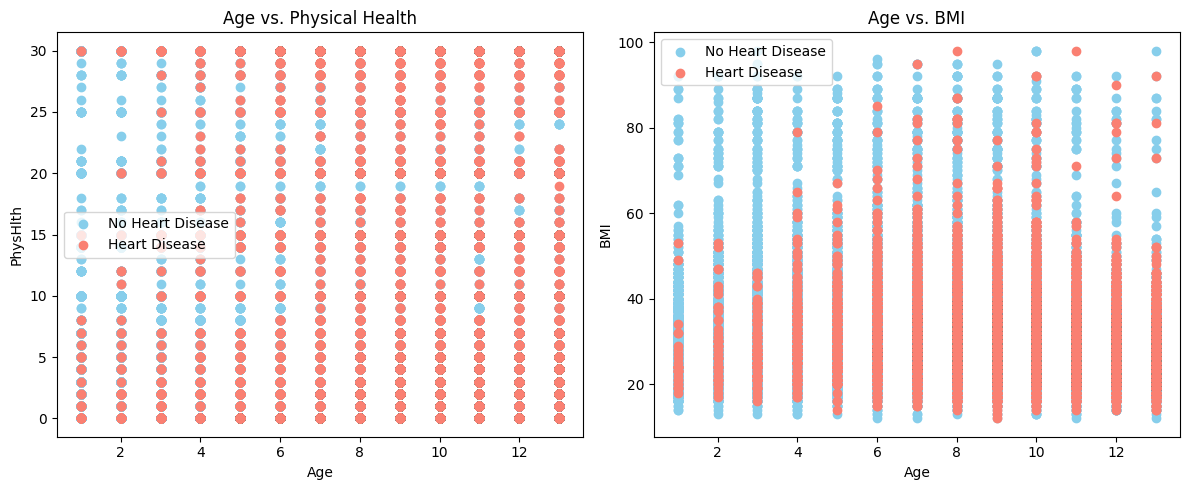

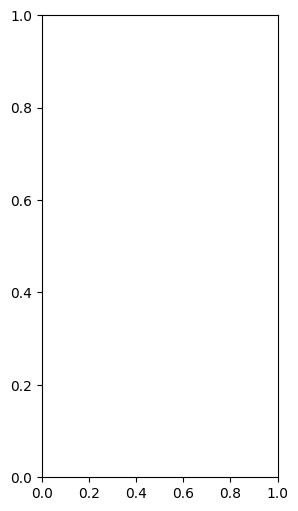

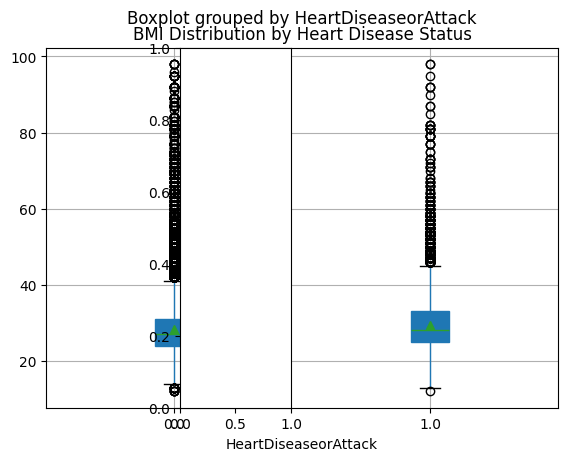

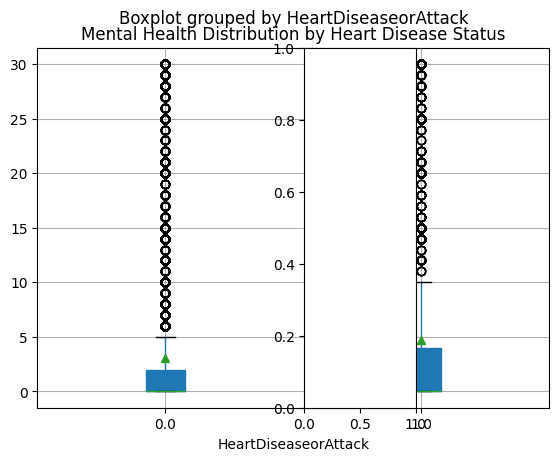

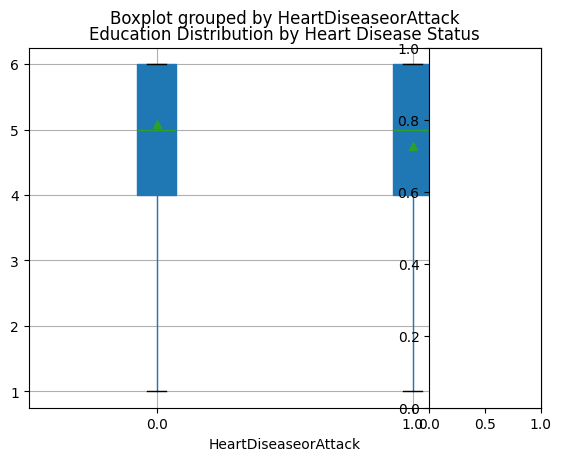

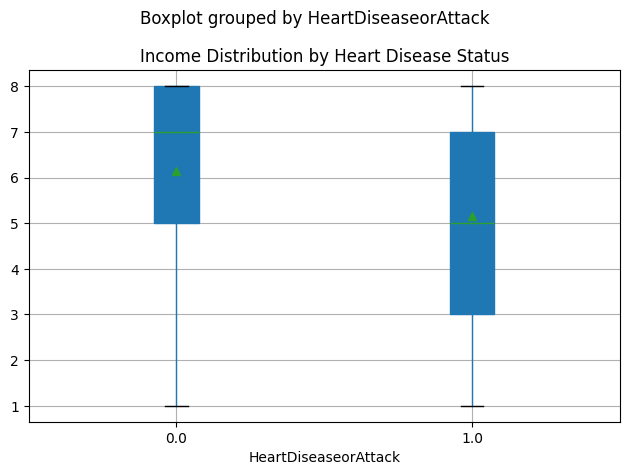

In [4]:
import matplotlib.pyplot as plt

# Scatter plots for 'Age', 'PhysHlth' vs. 'HeartDiseaseorAttack'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df[df['HeartDiseaseorAttack'] == 0]['Age'], df[df['HeartDiseaseorAttack'] == 0]['PhysHlth'], color='skyblue', label='No Heart Disease')
plt.scatter(df[df['HeartDiseaseorAttack'] == 1]['Age'], df[df['HeartDiseaseorAttack'] == 1]['PhysHlth'], color='salmon', label='Heart Disease')
plt.xlabel('Age')
plt.ylabel('PhysHlth')
plt.title('Age vs. Physical Health')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(df[df['HeartDiseaseorAttack'] == 0]['Age'], df[df['HeartDiseaseorAttack'] == 0]['BMI'], color='skyblue', label='No Heart Disease')
plt.scatter(df[df['HeartDiseaseorAttack'] == 1]['Age'], df[df['HeartDiseaseorAttack'] == 1]['BMI'], color='salmon', label='Heart Disease')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs. BMI')
plt.legend()

plt.tight_layout()
plt.show()


# Box plots for 'BMI', 'MentHlth', 'Education', and 'Income'
plt.figure(figsize=(14, 6))

plt.subplot(1, 4, 1)
df.boxplot(column='BMI', by='HeartDiseaseorAttack', patch_artist=True, showmeans=True)
plt.title('BMI Distribution by Heart Disease Status')

plt.subplot(1, 4, 2)
df.boxplot(column='MentHlth', by='HeartDiseaseorAttack', patch_artist=True, showmeans=True)
plt.title('Mental Health Distribution by Heart Disease Status')

plt.subplot(1, 4, 3)
df.boxplot(column='Education', by='HeartDiseaseorAttack', patch_artist=True, showmeans=True)
plt.title('Education Distribution by Heart Disease Status')

plt.subplot(1, 4, 4)
df.boxplot(column='Income', by='HeartDiseaseorAttack', patch_artist=True, showmeans=True)
plt.title('Income Distribution by Heart Disease Status')

plt.tight_layout()
plt.show()

**Key findings**

The analysis aims to identify which numerical features are associated with heart attacks.
 Based on the correlation analysis and visualizations,  'Age' and 'Physical health' show a moderate positive correlation with 'HeartDiseaseorAttack', while 'Education' and 'Income' show a weak negative correlation.
  'BMI' and 'MentHlth' have weak positive correlations.


**Data Analysis Key Findings**

* **Moderate Positive Correlation:** 'Age' (0.22) and 'PhysHlth' (0.18) show a moderate positive correlation with 'HeartDiseaseorAttack'.  

This suggests that as age and physical health issues increase, the likelihood of heart disease or attack also increases.

* **Weak Negative Correlation:** 'Education' (-0.10) and 'Income' (-0.14) exhibit weak negative correlations with 'HeartDiseaseorAttack'.  This suggests a slightly lower likelihood of heart disease or attack with higher education and income levels, though the relationship is not strong.

* **Weak Positive Correlation:**  'BMI' (0.05) and 'MentHlth' (0.06) have weak positive correlations, indicating a slight association with heart disease or attack.


